<a href="https://colab.research.google.com/github/noureldin75/RetinaGrade/blob/nour/eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!git clone -b nour https://github.com/noureldin75/RetinaGrade.git

%cd RetinaGrade

Cloning into 'RetinaGrade'...
remote: Enumerating objects: 3, done.
remote: Counting objects: 100% (3/3), done.
remote: Total 3 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (3/3), done.
/content/RetinaGrade


In [2]:
!mkdir -p data notebooks src

In [5]:
!mkdir -p ~/.kaggle
!cp /content/kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle competitions download -c aptos2019-blindness-detection -p ./data

!unzip -q ./data/aptos2019-blindness-detection.zip -d ./data

100% 9.51G/9.51G [01:06<00:00, 153MB/s]



In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

train_df=pd.read_csv('./data/train.csv')
print(f"Shape: {train_df.shape}")
print(f"Columns: {train_df.columns.tolist()}")
print(f"Missing values: {train_df.isnull().sum()}\n")
print(train_df.head())


Shape: (3662, 2)
Columns: ['id_code', 'diagnosis']
Missing values: id_code      0
diagnosis    0
dtype: int64

        id_code  diagnosis
0  000c1434d8d7          2
1  001639a390f0          4
2  0024cdab0c1e          1
3  002c21358ce6          0
4  005b95c28852          0


In [7]:
print(f"{train_df['diagnosis'].value_counts().sort_index()}")


diagnosis
0    1805
1     370
2     999
3     193
4     295
Name: count, dtype: int64


In [8]:
# --- Verify every listed image actually exists on disk ---
image_dir = './data/train_images'
missing_files = []

for img_id in train_df['id_code']:
    # APTOS images are .png
    path = os.path.join(image_dir, f"{img_id}.png")
    if not os.path.exists(path):
        missing_files.append(img_id)

print(f"\nImages listed in CSV: {len(train_df)}")
print(f"Missing image files: {len(missing_files)}")
if missing_files:
    print(missing_files[:10])  # show a sample


Images listed in CSV: 3662
Missing image files: 0


In [9]:
image_dir='./data/train_images'
missing_images=[]
for id in train_df['id_code']:
  path=os.path.join(image_dir,f"{id}.png")
  if not os.path.exists(path):
    missing_files.append(id)
print(f"\nImages listed in CSV: {len(train_df)}")
print(f"Missing image files: {len(missing_files)}")


Images listed in CSV: 3662
Missing image files: 0


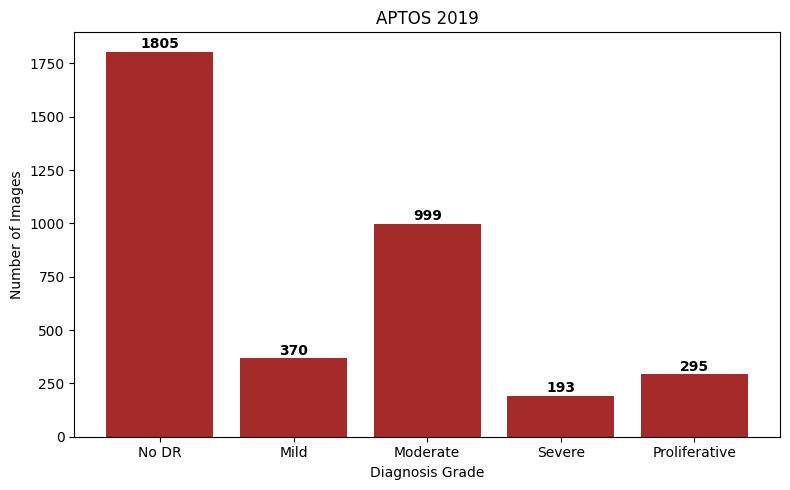

In [10]:
import matplotlib.pyplot as plt

grade_labels = {
    0: 'No DR',
    1: 'Mild',
    2: 'Moderate',
    3: 'Severe',
    4: 'Proliferative'
}

counts = train_df['diagnosis'].value_counts().sort_index()
labels=[]
for i in counts.index:
  labels.append(grade_labels[i])

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(labels, counts.values, color='brown')
ax.set_xlabel('Diagnosis Grade')
ax.set_ylabel('Number of Images')
ax.set_title('APTOS 2019')

for bar, count in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
            str(count), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()



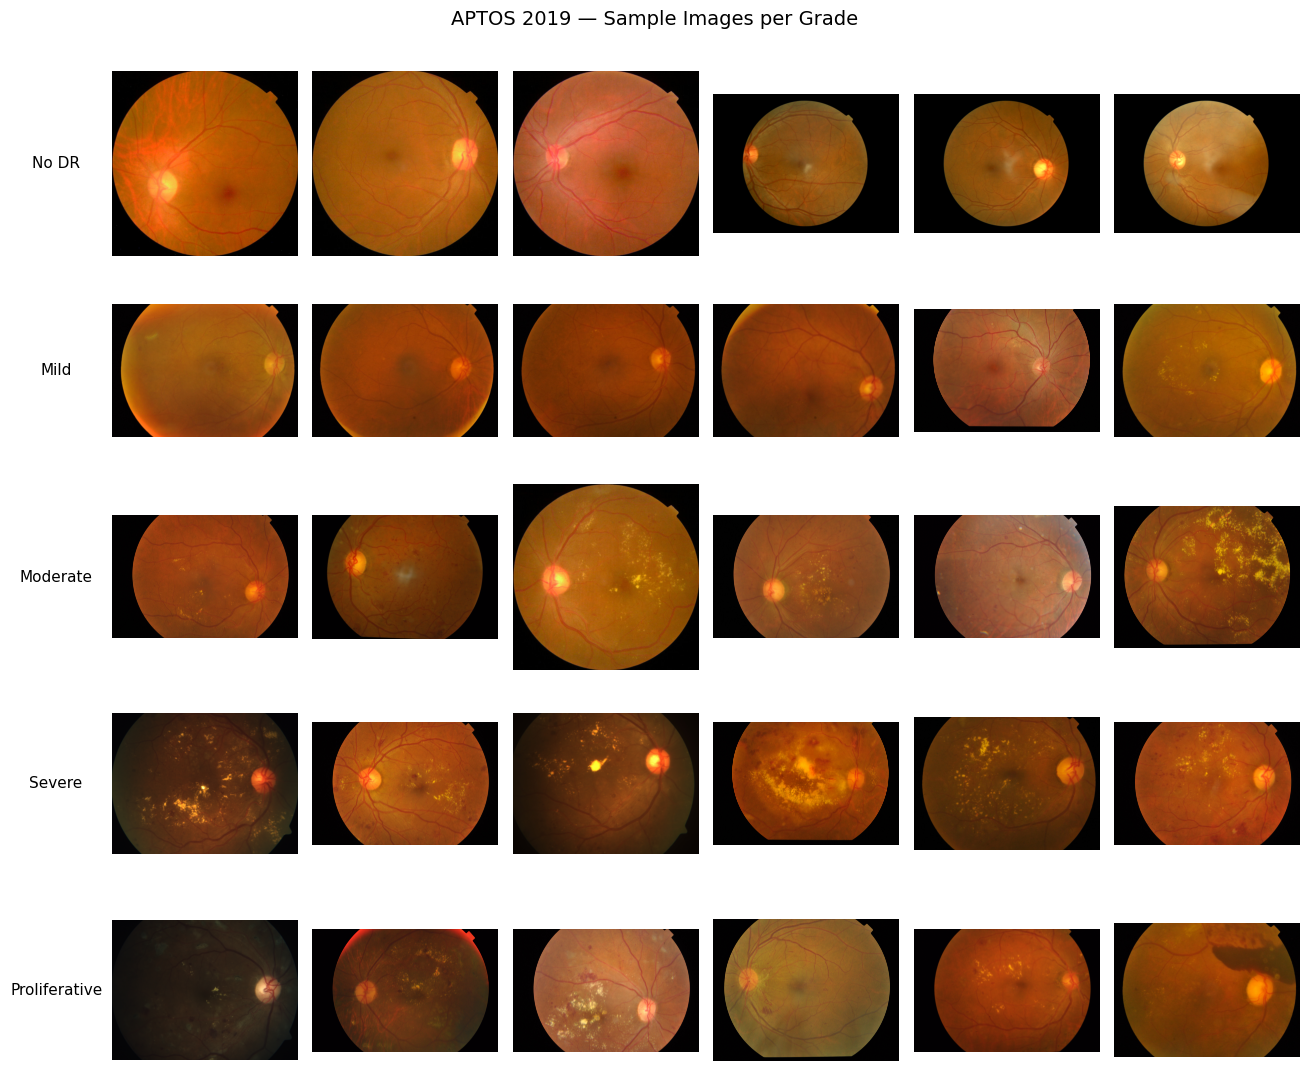

In [15]:
import numpy as np
from PIL import Image

n_samples = 6  # images per class
grades = sorted(grade_labels.keys())

fig, axes = plt.subplots(len(grades), n_samples, figsize=(n_samples * 2.2, len(grades) * 2.2))

rng = np.random.default_rng(42)  # reproducible sampling

for row, grade in enumerate(grades):
    # Get all image ids for this grade
    subset = train_df[train_df['diagnosis'] == grade]['id_code'].values
    sample_ids = rng.choice(subset, size=min(n_samples, len(subset)), replace=False)

    for col, img_id in enumerate(sample_ids):
        img_path = os.path.join(image_dir, f"{img_id}.png")
        img = Image.open(img_path)

        ax = axes[row, col]
        ax.imshow(img)
        ax.axis('off')

        if col == 0:
            ax.set_ylabel(grade_labels[grade], fontsize=11, rotation=0,
                          labelpad=40, va='center')
            ax.axis('on')
            ax.set_xticks([])
            ax.set_yticks([])
            for spine in ax.spines.values():
                spine.set_visible(False)

plt.suptitle('APTOS 2019 — Sample Images per Grade', fontsize=14, y=1.0)
plt.tight_layout()
plt.show()

In [16]:
from PIL import Image
import os

sizes = []

for img_id in train_df['id_code']:
    path = os.path.join(image_dir, f"{img_id}.png")
    with Image.open(path) as img:
        sizes.append(img.size)

print("First 10 image sizes:")
print(sizes[:10])

print("\nUnique image sizes:")
print(len(set(sizes)))

First 10 image sizes:
[(3216, 2136), (3216, 2136), (2416, 1736), (1050, 1050), (2048, 1536), (3388, 2588), (2588, 1958), (3216, 2136), (2588, 1958), (2416, 1736)]

Unique image sizes:
17


In [17]:
modes = []

for img_id in train_df['id_code'].sample(100, random_state=42):
    path = os.path.join(image_dir, f"{img_id}.png")
    with Image.open(path) as img:
        modes.append(img.mode)

print(set(modes))

{'RGB'}


In [19]:
!mkdir -p data
!echo "data/" > .gitignore
!echo "kaggle.json" >> .gitignore